In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [2]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\1HZL.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27029 entries, 0 to 27028
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  27029 non-null  str  
 1   Message  27029 non-null  str  
 2   Status   27029 non-null  str  
dtypes: str(3)
memory usage: 633.6 KB


In [3]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [4]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-09-04 13:08:03.728 Last fuel report fs02:  2026-09-04 13:08:03.169


In [5]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 253.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 4447 entries, 0 to 4446
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     4447 non-null   int64
 1   date      4447 non-null   str  
 2   raw data  4447 non-null   str  
dtypes: int64(1), str(2)
memory usage: 104.4 KB


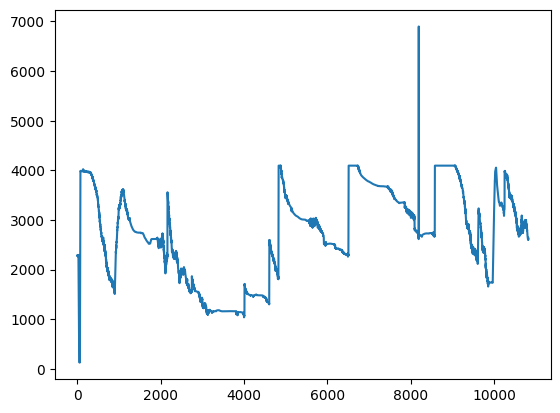

In [6]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

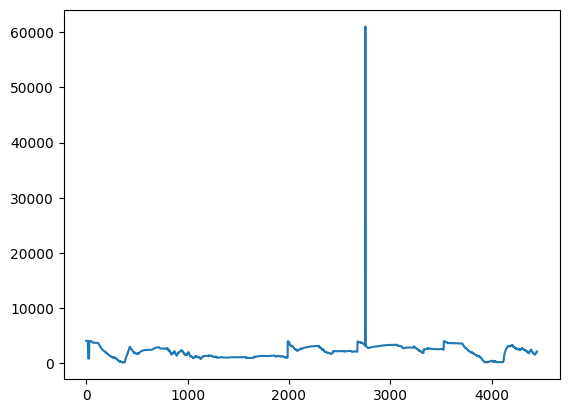

In [7]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [8]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

8190 0x25252100242CF5086948706020102626083115201801013E01071FF31A3FFBFB0AEFAF3B -> 260819150030 6899


In [9]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 338.1 KB


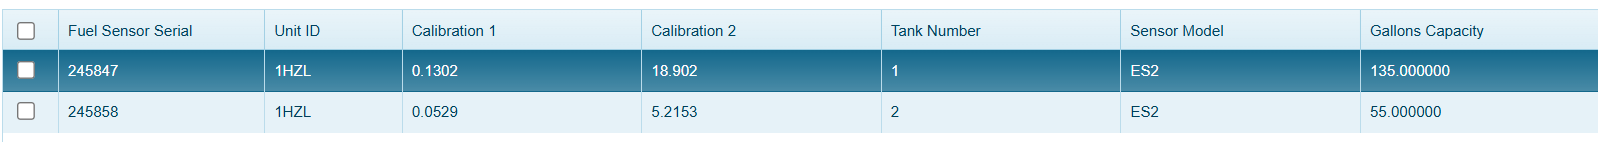

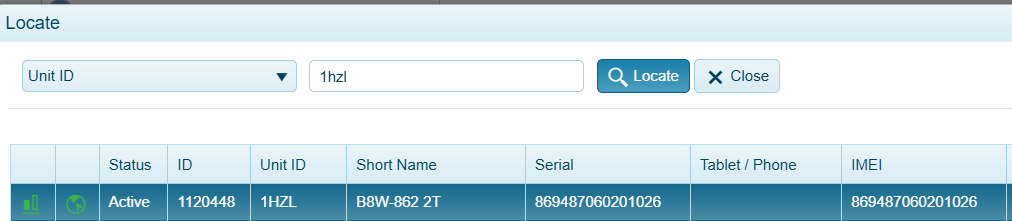

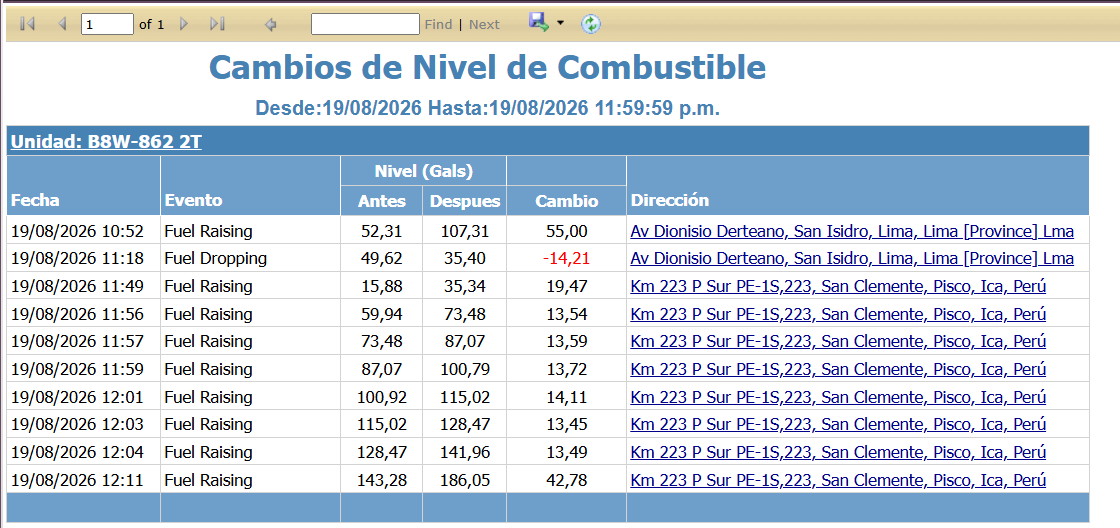

In [10]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.1302
b1=18.902
m2=0.0529
b2=5.2153

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
Index: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 338.1 KB


In [11]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vahice is parked, p=0

date1=260819164716
date2=260819171251

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>=(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<=(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>=(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<=(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
raising 24.380120314512663 4.912437536521785 19.467682777990877
raising 31.603112157936838 24.380120314512663 26.690674621415052
raising 40.16751677228265 31.603112157936838 35.25507923576087
raising 48.97268778140926 40.16751677228265 44.06025024488748
raising 62.5243962876432 48.97268778140926 57.61195875112141
raising 76.11049999313154 62.5243962876432 71.19806245660976
raising 89.83418449563747 76.11049999313154 84.9217469591157
raising 103.93621618994182 89.83418449563747 99.02377865342004
raising 117.38473909841255 103.93621618994182 112.47230156189077
raising 130.8676572061377 117.38473909841255 125.95521966961591
raising 131.9683035822785 130.8676572061377 127.05586604575673
droping 131.8651179845153 131.9683035822785 126.95268044799353
raising 131.8651179845153 131.8651179845153 126.95268044799353
droping 131.8651179845153 131.8651179845153 126.95268044799353
raising 132.24346517631372 131.8651

Adding the validation to delete the value that beongs to ragistger i+1.

In [12]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260819164716
date2=260819171251
level=0


print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 24.380120314512663 4.912437536521785 19.467682777990877 19.467682777990877
raising 31.603112157936838 24.380120314512663 26.690674621415052 7.222991843424175
raising 40.16751677228265 31.603112157936838 35.25507923576087 8.564404614345815
raising 48.97268778140926 40.16751677228265 44.06025024488748 8.80517100912661
raising 62.5243962876432 48.97268778140926 57.61195875112141 13.551708506233936
raising 76.11049999313154 62.5243962876432 71.19806245660976 13.586103705488341
raising 89.83418449563747 76.11049999313154 84.9217469591157 13.723684502505932
raising 103.93621618994182 89.83418449563747 99.02377865342004 14.102031694304344
raising 117.38473909841255 103.93621618994182 112.47230156189077 13.448522908470736
raising 130.8676572061377 117.38473909841255 125.95521966961591 13.48291810772514
raising 131.9683035822785 130.8676572061377 127.05586604575673 1.1006463761408156
droping 131